## 1. Setup & Librerie / Setup & Libraries

**In italiano:** In questa sezione prepariamo l'ambiente. Se il notebook viene eseguito su **Google Colab**, le librerie necessarie verranno installate automaticamente.
Effettuiamo un controllo dinamico dell'hardware per supportare in modo trasparente sia **GPU (CUDA)** che **TPU (XLA)**. Hugging Face `Trainer` gestirà in automatico il posizionamento del modello sul device corretto. Inoltre, impostiamo le variabili per attivare la precisione mista ottimale: **FP16** per la GPU T4 e **BF16** per la TPU v5e-1.

**In English:** In this section, we prepare the environment. If the notebook is executed on **Google Colab**, the required libraries will be installed automatically.
We perform a dynamic hardware check to seamlessly support both **GPU (CUDA)** and **TPU (XLA)**. Hugging Face `Trainer` will automatically handle placing the model on the correct device. Additionally, we set variables to enable the optimal mixed precision: **FP16** for the T4 GPU and **BF16** for the v5e-1 TPU.

In [14]:
import sys
import os

# Installazione automatica delle librerie e RAPIDS cudf per GPU
if 'google.colab' in sys.modules:
    print("Installazione pacchetti e supporto GPU (cudf)...")
    !pip install -q transformers[torch] datasets accelerate scikit-learn matplotlib seaborn
    # Installiamo cudf per pandas su GPU (preinstallato su molte istanze Colab)
    try:
        import cudf
    except ImportError:
        !pip install -q --extra-index-url=https://pypi.nvidia.com cudf-cu12

import torch
import pandas as pd
try:
    import cudf
    import cudf.pandas
    cudf.pandas.install() # Abilita l'accelerazione GPU trasparente per pandas
    print("Accelerazione GPU per pandas (cudf) attivata!")
except ImportError:
    print("cudf non trovato, procedo con pandas standard.")

from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurazione hardware
device = "cuda" if torch.cuda.is_available() else "cpu"
use_fp16 = torch.cuda.is_available()
use_bf16 = False

Installazione pacchetti e supporto GPU (cudf)...
Accelerazione GPU per pandas (cudf) attivata!


## 2. Caricamento e Preprocessing dei Dati / Data Loading & Preprocessing

**In italiano:** Carichiamo un sottoinsieme del dataset FEVER per ottimizzare i tempi di esecuzione, ideale per un fine-tuning su risorse limitate. Successivamente, mappiamo le etichette originali nel formato richiesto da un approccio NLI classico: `SUPPORTS` diventa 0 (Entailment), `REFUTES` diventa 1 (Contradiction) e `NOT ENOUGH INFO` diventa 2 (Neutral).

**In English:** We load a subset of the FEVER dataset to optimize execution times, which is ideal for fine-tuning on limited resources. Next, we map the original labels to the format required by a classic NLI approach: `SUPPORTS` becomes 0 (Entailment), `REFUTES` becomes 1 (Contradiction), and `NOT ENOUGH INFO` becomes 2 (Neutral).

In [15]:
import pandas as pd
import json
from datasets import Dataset

# Caricamento del file usando pandas (ora accelerato da GPU tramite cudf)
print("Caricamento dati su GPU in corso...")
df = pd.read_json('/content/train.jsonl', lines=True, nrows=6000)

# Pulizia e preparazione rapida
df = df[['label', 'claim', 'evidence']]
df['evidence'] = df['evidence'].astype(str)
df['claim'] = df['claim'].astype(str)
df['label'] = df['label'].astype(str)

# Mappatura etichette
label_map = {'SUPPORTS': 0, 'REFUTES': 1, 'NOT ENOUGH INFO': 2}
def map_label_val(l):
    return label_map.get(l, 2)

df['label'] = df['label'].apply(map_label_val)

# Convertiamo in un Dataset di Hugging Face per il training
# Utilizziamo .to_pandas() se il dataframe è un oggetto cudf
full_dataset = Dataset.from_pandas(df.to_pandas() if hasattr(df, 'to_pandas') else df)

# Suddividiamo il dataset filtrato in train e validation
splitted_dataset = full_dataset.train_test_split(train_size=5000, test_size=1000, seed=42)

train_dataset = splitted_dataset['train']
val_dataset = splitted_dataset['test']

print(f"Dataset pronto (via GPU): {len(train_dataset)} train, {len(val_dataset)} validation.")

Caricamento dati su GPU in corso...
Dataset pronto (via GPU): 5000 train, 1000 validation.


## 3. Tokenizzazione Cross-Encoder / Cross-Encoder Tokenization

**In italiano:** La particolarità dell'architettura Cross-Encoder è che elabora simultaneamente sia la Premessa (l'Evidenza) che l'Ipotesi (la Notizia/Claim). Il tokenizzatore di DeBERTa le unisce inserendo tra di esse il token speciale `[SEP]`. In questo modo, il meccanismo di attenzione del modello calcola interazioni profonde tra le parole della premessa e dell'ipotesi a ogni livello dell'architettura.

**In English:** The uniqueness of the Cross-Encoder architecture is that it simultaneously processes both the Premise (Evidence) and the Hypothesis (News/Claim). The DeBERTa tokenizer joins them by inserting the special token `[SEP]` in between. This way, the model's self-attention mechanism computes deep cross-interactions between the words of the premise and the hypothesis at every layer of the architecture.

In [16]:
model_name = "cross-encoder/nli-deberta-v3-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    # Assicuriamoci che i dati siano stringhe.
    # In molti file FEVER, 'claim' è una stringa, ma 'evidence' può essere strutturato.
    # Se 'evidence' non è presente o è vuoto, usiamo una stringa vuota per evitare errori.
    claims = [str(c) if c is not None else "" for c in examples['claim']]
    evidences = [str(e) if e is not None else "" for e in examples['evidence']]

    return tokenizer(evidences, claims, padding="max_length", truncation=True, max_length=256)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

# Impostiamo il formato dei dati per PyTorch
tokenized_train.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_val.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

## 4. Definizione del Modello e Iperparametri / Model Definition & Hyperparameters

**In italiano:** Carichiamo il modello `cross-encoder/nli-deberta-v3-large` pre-addestrato specificando che avrà 3 etichette di classificazione (0, 1, 2). Successivamente, configuriamo i `TrainingArguments` con iperparametri bilanciati per risorse limitate: un learning rate di `2e-5`, un batch size di `8` e un numero ridotto di epoche (`2`), per garantire un addestramento veloce e stabile.

**In English:** We load the pre-trained `cross-encoder/nli-deberta-v3-large` model, specifying that it will have 3 classification labels (0, 1, 2). Next, we configure the `TrainingArguments` with hyperparameters balanced for limited resources: a learning rate of `2e-5`, a batch size of `8`, and a reduced number of epochs (`2`), ensuring fast and stable training.

In [17]:
# Carichiamo il modello pre-addestrato per Sequence Classification con 3 labels
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3, ignore_mismatched_sizes=True)

# Definizione degli argomenti per il training con gestione dinamica della precisione mista (FP16 o BF16)
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    load_best_model_at_end=True,
    fp16=use_fp16,       # True solo se usiamo GPU (es. T4)
    bf16=use_bf16,       # True solo se usiamo TPU (es. v5e-1)
)

model.safetensors:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## 5. Fase di Addestramento / Training Phase

**In italiano:** Inizializziamo il `Trainer` di Hugging Face passando il modello, gli argomenti di training, i dataset di train e validazione, e la funzione per calcolare le metriche personalizzate che definiremo nel prossimo step. Avviando `trainer.train()`, il modello adatterà i suoi pesi specificamente al task di fact-checking basato su FEVER.

**In English:** We initialize the Hugging Face `Trainer` by passing the model, the training arguments, the train and validation datasets, and a custom metrics computation function we will define in the next step. By running `trainer.train()`, the model will adapt its weights specifically to the FEVER-based fact-checking task.

In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)
    # Usiamo l'average macro per avere un'idea bilanciata su tutte le 3 classi
    precision = precision_score(labels, predictions, average='macro', zero_division=0)
    recall = recall_score(labels, predictions, average='macro', zero_division=0)
    f1 = f1_score(labels, predictions, average='macro', zero_division=0)

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Inizializziamo il Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

# Avvio dell'addestramento
print("Avvio del training...")
train_result = trainer.train()

Avvio del training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.314515,0.283825,0.905000,0.915342,0.852853,0.873094
2,0.191000,0.329258,0.917000,0.908138,0.891699,0.898961


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 6. Valutazione e Metriche / Evaluation & Metrics

**In italiano:** Eseguiamo l'inferenza finale sul test set (validation set) per verificare le performance reali. Utilizziamo `scikit-learn` per calcolare non solo l'Accuracy, ma soprattutto la Precision, la Recall e l'F1-Score, metriche fondamentali per valutare modelli di NLI dove i falsi positivi/negativi hanno un forte impatto nel fact-checking.

**In English:** We run the final inference on the test set (validation set) to verify real performance. We use `scikit-learn` to calculate not just Accuracy, but primarily Precision, Recall, and the F1-Score. These are critical metrics for evaluating NLI models where false positives/negatives heavily impact fact-checking.

In [19]:
print("Valutazione sul validation set...")
metrics = trainer.evaluate()

print(f"Accuracy:  {metrics['eval_accuracy']:.4f}")
print(f"Precision: {metrics['eval_precision']:.4f}")
print(f"Recall:    {metrics['eval_recall']:.4f}")
print(f"F1-Score:  {metrics['eval_f1']:.4f}")

# Generiamo predizioni per la matrice di confusione
predictions, labels, _ = trainer.predict(tokenized_val)
predicted_labels = np.argmax(predictions, axis=-1)

Valutazione sul validation set...


Accuracy:  0.9050
Precision: 0.9153
Recall:    0.8529
F1-Score:  0.8731


## 7. Comparazione con il Modello Base / Baseline Model Comparison

**In italiano:** Per misurare l'effettivo miglioramento portato dal fine-tuning, valutiamo anche il modello base (`cross-encoder/nli-deberta-v3-large`) non fine-tunato sullo stesso validation set. In questo modo possiamo quantificare l'incremento di performance sulle metriche principali.

**In English:** To measure the actual improvement brought by fine-tuning, we also evaluate the base (non-fine-tuned) model (`cross-encoder/nli-deberta-v3-large`) on the same validation set. This allows us to quantify the performance boost on the main metrics.

In [20]:
print("Valutazione del modello base (non fine-tunato) sul validation set...")
# Carichiamo una nuova istanza del modello base originale
base_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3, ignore_mismatched_sizes=True)

# Inizializziamo un Trainer solo per la valutazione del modello base
base_trainer = Trainer(
    model=base_model,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

base_metrics = base_trainer.evaluate()

print("\n--- Confronto / Comparison ---")
print(f"Accuracy  | Base: {base_metrics['eval_accuracy']:.4f} -> Fine-tuned: {metrics['eval_accuracy']:.4f}")
print(f"Precision | Base: {base_metrics['eval_precision']:.4f} -> Fine-tuned: {metrics['eval_precision']:.4f}")
print(f"Recall    | Base: {base_metrics['eval_recall']:.4f} -> Fine-tuned: {metrics['eval_recall']:.4f}")
print(f"F1-Score  | Base: {base_metrics['eval_f1']:.4f} -> Fine-tuned: {metrics['eval_f1']:.4f}")

Valutazione del modello base (non fine-tunato) sul validation set...


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Confronto / Comparison ---
Accuracy  | Base: 0.1240 -> Fine-tuned: 0.9050
Precision | Base: 0.0844 -> Fine-tuned: 0.9153
Recall    | Base: 0.1367 -> Fine-tuned: 0.8529
F1-Score  | Base: 0.0963 -> Fine-tuned: 0.8731


## 8. Visualizzazione dei Risultati / Results Visualization

**In italiano:** Analizziamo visivamente i risultati:
1. **Line plot (Loss):** Mostra la discesa della Training e Validation Loss durante le epoche. Una validation loss che diverge indica overfitting.
2. **Confusion Matrix:** Rivela le vere performance per ogni specifica classe. Ci fa capire se il modello confonde spesso, ad esempio, `Contradiction` con `Neutral`.

**In English:** Let's visually analyze the results:
1. **Line plot (Loss):** Shows the descent of the Training and Validation Loss over epochs. A diverging validation loss indicates overfitting.
2. **Confusion Matrix:** Reveals true performance per specific class. It helps us understand if the model often confuses, for instance, `Contradiction` with `Neutral`.

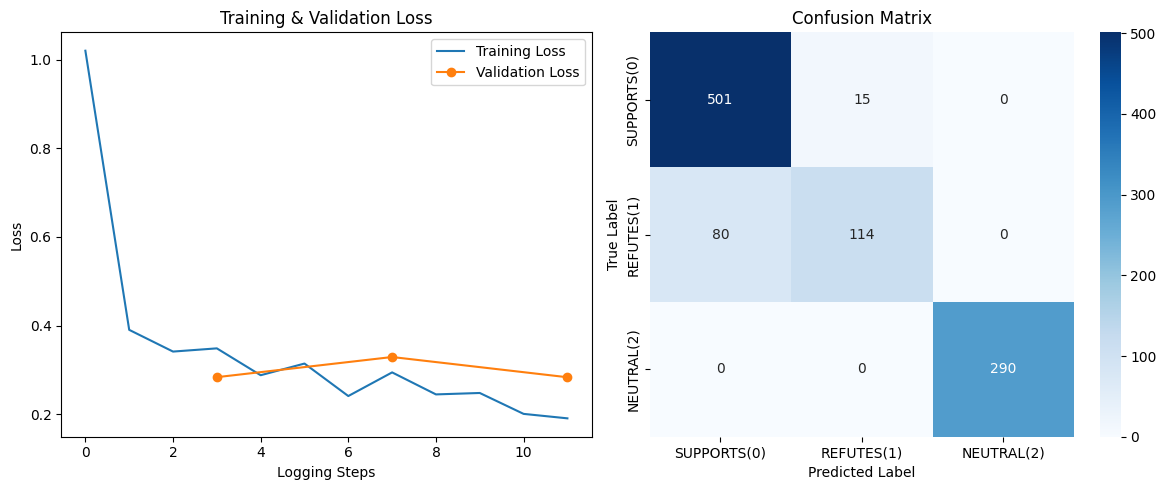

In [21]:
# Estraiamo le loss dalla history del trainer
train_history = trainer.state.log_history
train_loss = [x['loss'] for x in train_history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in train_history if 'eval_loss' in x]

plt.figure(figsize=(12, 5))

# 1. Line Plot: Training vs Validation Loss
plt.subplot(1, 2, 1)
if len(train_loss) > 0:
    plt.plot(train_loss, label='Training Loss')
if len(eval_loss) > 0:
    step_size = len(train_loss) / len(eval_loss) if len(eval_loss) > 0 else 1
    eval_steps = [int((i+1)*step_size)-1 for i in range(len(eval_loss))]
    plt.plot(eval_steps, eval_loss, label='Validation Loss', marker='o')

plt.title('Training & Validation Loss')
plt.xlabel('Logging Steps')
plt.ylabel('Loss')
plt.legend()

# 2. Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['SUPPORTS(0)', 'REFUTES(1)', 'NEUTRAL(2)'],
            yticklabels=['SUPPORTS(0)', 'REFUTES(1)', 'NEUTRAL(2)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

## 9. Salvataggio del Modello / Model Saving

**In italiano:** Infine, salviamo localmente i pesi del modello fine-tunato e il tokenizzatore. Questo permetterà di ricaricare il classificatore NLI ottimizzato in futuro senza dover ripetere il processo di addestramento.

**In English:** Finally, we save the fine-tuned model's weights and the tokenizer locally. This will allow us to reload the optimized NLI classifier in the future without having to repeat the training process.

In [22]:
output_model_dir = "./fever-nli-deberta-large"

print(f"Salvataggio del modello in {output_model_dir}...")
model.save_pretrained(output_model_dir)
tokenizer.save_pretrained(output_model_dir)
print("Salvataggio completato con successo!")

Salvataggio del modello in ./fever-nli-deberta-large...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Salvataggio completato con successo!
